## 1) Imports

In [21]:
from pathlib import Path
from datetime import datetime, timezone
import json
import warnings

import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

import yaml

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

## 2) Paths and Config

In [22]:
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CFG_PATH = REPO_ROOT / 'config' / 'paths.local.yaml'
if not CFG_PATH.exists():
    CFG_PATH = REPO_ROOT / 'config' / 'paths.template.yaml'
if not CFG_PATH.exists():
    raise FileNotFoundError('Missing config/paths.local.yaml and config/paths.template.yaml')

cfg = yaml.safe_load(CFG_PATH.read_text(encoding='utf-8')) or {}
shared_cfg = cfg.get('shared', {})
repo_cfg   = cfg.get('repo', {})

DATA_PATH = Path(shared_cfg['modeling_input'])
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {DATA_PATH}')

RUN_ID       = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
RUNS_BASE    = REPO_ROOT / repo_cfg.get('modeling_runs_dir', 'results/runs/modeling')
RUN_DIR      = RUNS_BASE / f'run02_{RUN_ID}'

# Path to ml_modeling_01 baseline results (most recent run)
BASELINE_DIR = sorted(RUNS_BASE.glob('run_*'))[-1] if list(RUNS_BASE.glob('run_*')) else None

print('Dataset:    ', DATA_PATH)
print('Run dir:    ', RUN_DIR)
print('Baseline:   ', BASELINE_DIR)

Dataset:     /share/ml-data/integrated_all_merged_final.parquet
Run dir:     /share/project_repo/zzhan342/WiFiMLCapstoneS2026/results/runs/modeling/run02_20260411T214723Z
Baseline:    /share/project_repo/zzhan342/WiFiMLCapstoneS2026/results/runs/modeling/run_20260409T051717Z


## 3) Settings

In [23]:
RANDOM_STATE = 42
MAX_ROWS     = 5_000_000   # None = full dataset

# Val fraction carved out of train for threshold tuning (not seen during training)
VAL_FRACTION = 0.1

STATE_N_SPLITS      = 5
STATE_MAX_TRAIN_ROWS = 5_000_000
DROP_UNKNOWN_FOR_BINARY = True
OHE_MAX_CATEGORIES  = 67

TARGET_COL  = 'label_sensitive_binary'
SPLIT_MODES = ['random', 'state']

# Models to run in this notebook (subset of MODEL_REGISTRY)
MODELS_TO_RUN = ['sgd', 'dtree', 'xgb']

# Class weights to sweep in Section 8.
# 'balanced' = sklearn auto-balanced; dict = manual ratio {neg: pos}
CLASS_WEIGHT_SWEEP = [
    'balanced',          # same as ml_modeling_01 baseline
    {0: 1, 1: 5},
    {0: 1, 1: 10},
    {0: 1, 1: 20},
]

_BASE_EXCLUDE = {'label_target_main', 'label_sensitive_binary', 'label_sensitive_subtype', 'add_state'}

# ── Stage B: threshold selection constraint ───────────────────────────────────
# Assumption: for sensitive-device detection, missing a positive (FN) costs more
# than a false alarm (FP).  We require precision >= this floor on the val set,
# then pick the threshold that maximises recall among those that qualify.
# Set None to fall back to argmax(macro_f1) — the original behaviour.
THRESH_MIN_PRECISION = 0.70

## 4) Load Data

In [24]:
_df_pl = pl.read_parquet(DATA_PATH)
if MAX_ROWS and len(_df_pl) > MAX_ROWS:
    _df_pl = _df_pl.sample(n=MAX_ROWS, seed=RANDOM_STATE, shuffle=True)
df_full = _df_pl.to_pandas()
del _df_pl

# Drop rows where binary target is unknown
if DROP_UNKNOWN_FOR_BINARY:
    mask = df_full.get('label_target_main', pd.Series('ok', index=df_full.index)) != 'unknown'
    df_full = df_full[mask].copy()

df_full = df_full[df_full[TARGET_COL].notna()].copy()
print(f'Working dataset: {len(df_full):,} rows')
print(f'Class distribution:\n{df_full[TARGET_COL].value_counts()}')

Working dataset: 4,405,023 rows
Class distribution:
label_sensitive_binary
0    4132300
1     272723
Name: count, dtype: int64


## 5) Baseline: ml_modeling_01 Results

Load the summary CSV from the most recent `run_*` folder for reference.

In [25]:
if BASELINE_DIR and (BASELINE_DIR / 'summary_metrics.csv').exists():
    baseline = pd.read_csv(BASELINE_DIR / 'summary_metrics.csv')
    baseline_binary = baseline[baseline['target'] == TARGET_COL].copy()
    summary_01 = (
        baseline_binary
        .groupby('model')[['accuracy', 'macro_f1', 'weighted_f1', 'pr_auc', 'roc_auc']]
        .mean()
        .round(4)
        .sort_values('macro_f1', ascending=False)
    )
    print(f'Baseline from: {BASELINE_DIR.name}')
    display(summary_01)
else:
    print('No baseline found — run ml_modeling_01 first.')
    baseline_binary = pd.DataFrame()

Baseline from: run_20260409T051717Z


,accuracy,macro_f1,weighted_f1,pr_auc,roc_auc
model,,,,,
sgd,0.8454,0.6250,0.8768,0.2462,0.8164
dtree,0.8397,0.6209,0.8732,0.2470,0.8177


## 6) Pipeline Helpers

In [26]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

def build_split_folds(df, split_mode):
    """Yield (fold_id, train_idx, test_idx)."""
    if split_mode == 'random':
        train_idx, test_idx = train_test_split(
            df.index, test_size=0.2, random_state=RANDOM_STATE, shuffle=True,
        )
        yield 'random_fold_1', train_idx, test_idx

    elif split_mode == 'state':
        states = df['add_state'].unique()
        np.random.seed(RANDOM_STATE)
        np.random.shuffle(states)
        folds = np.array_split(states, STATE_N_SPLITS)
        for k, held in enumerate(folds, 1):
            test_idx  = df.index[df['add_state'].isin(held)]
            train_idx = df.index[~df['add_state'].isin(held)]
            if STATE_MAX_TRAIN_ROWS and len(train_idx) > STATE_MAX_TRAIN_ROWS:
                train_idx = train_idx[:STATE_MAX_TRAIN_ROWS]
            yield f'state_fold_{k}', train_idx, test_idx


def build_pipeline(model):
    """Preprocessing + classifier pipeline (mirrors ml_modeling_01)."""
    ohe = OneHotEncoder(
        max_categories=OHE_MAX_CATEGORIES, handle_unknown='infrequent_if_exist',
        sparse_output=False,
    )
    te = TargetEncoder(random_state=RANDOM_STATE)
    feature_cols = [c for c in df_full.columns if c not in _BASE_EXCLUDE]
    cat_cols  = ['vendor_clean']
    num_cols  = [c for c in feature_cols if c != 'vendor_clean']
    pre = ColumnTransformer([
        ('ohe', ohe, ['vendor_clean']),
        ('te',  te,  []),
        ('num', 'passthrough', num_cols),
    ], remainder='drop')
    return Pipeline([('pre', pre), ('clf', model)])


def find_best_threshold(pipe, X_val, y_val, min_precision=None):
    """Stage B threshold selection.

    If min_precision is set: among all thresholds where precision >= min_precision,
    pick the one with the highest recall (maximises true-positive capture under the
    precision floor).  Falls back to argmax(macro_f1) when no threshold qualifies.

    If min_precision is None: original argmax(macro_f1) behaviour.

    Returns (best_threshold, macro_f1_at_best_threshold).
    """
    proba = pipe.predict_proba(X_val)[:, 1]
    thresholds = np.arange(0.05, 0.95, 0.01)

    if min_precision is not None:
        valid = []
        for t in thresholds:
            pred = (proba >= t).astype(int)
            if pred.sum() == 0:
                continue
            p = precision_score(y_val, pred, zero_division=0)
            r = recall_score(y_val, pred, zero_division=0)
            if p >= min_precision:
                valid.append((float(t), r))
        if valid:
            best_t = max(valid, key=lambda x: x[1])[0]
            best_f1 = f1_score(y_val, (proba >= best_t).astype(int),
                               average='macro', zero_division=0)
            return best_t, float(best_f1)
        print(f'    [warn] No threshold achieves precision>={min_precision:.2f}; '
              f'falling back to argmax(macro_f1)')

    # Fallback: argmax macro F1
    scores = [f1_score(y_val, (proba >= t).astype(int), average='macro', zero_division=0)
              for t in thresholds]
    best_t = float(thresholds[np.argmax(scores)])
    return best_t, float(max(scores))


def build_threshold_curve(pipe, X, y):
    """Stage C: threshold operating curve.

    Returns a DataFrame with columns:
        threshold | precision | recall | f1_macro | fnr | fpr
    Covers the full [0.01, 0.99] range at 0.005 steps.
    """
    proba = pipe.predict_proba(X)[:, 1]
    rows = []
    for t in np.arange(0.01, 0.995, 0.005):
        pred = (proba >= t).astype(int)
        if pred.sum() == 0 or pred.sum() == len(pred):
            continue
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        rows.append({
            'threshold': round(float(t), 3),
            'precision': float(precision_score(y, pred, zero_division=0)),
            'recall':    float(recall_score(y, pred, zero_division=0)),
            'f1_macro':  float(f1_score(y, pred, average='macro', zero_division=0)),
            'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
            'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        })
    return pd.DataFrame(rows)


def evaluate_at_threshold(pipe, X_test, y_test, threshold):
    """Evaluate a fitted pipeline at a specific probability threshold."""
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= threshold).astype(int)
    out = {
        'threshold':   threshold,
        'accuracy':    float(accuracy_score(y_test, pred)),
        'macro_f1':    float(f1_score(y_test, pred, average='macro',    zero_division=0)),
        'weighted_f1': float(f1_score(y_test, pred, average='weighted', zero_division=0)),
        'pr_auc':      float(average_precision_score(y_test, proba)),
        'roc_auc':     float(roc_auc_score(y_test, proba)),
    }
    return out

## 7) Threshold Optimization

For each model and fold:
1. Further split the **train** portion into `train` / `val` (90/10).
2. Fit on `train`, search optimal threshold on `val` (maximise macro F1).
3. Evaluate on `test` at the optimal threshold.

Models use the same `class_weight='balanced'` as ml_modeling_01 for a fair comparison.

In [27]:
# Model factories with class_weight='balanced' (same as baseline)
THRESHOLD_MODELS = {
    'sgd': lambda: SGDClassifier(
        loss='log_loss', max_iter=1000, tol=1e-4,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=5,
        learning_rate='optimal', class_weight='balanced',
        random_state=RANDOM_STATE, shuffle=True, n_jobs=-1,
    ),
    'dtree': lambda: DecisionTreeClassifier(
        max_depth=5, class_weight='balanced', random_state=RANDOM_STATE,
    ),
    'xgb': lambda: XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=1, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
}

threshold_results = []
X_all = df_full[[c for c in df_full.columns if c not in _BASE_EXCLUDE]]
y_all = df_full[TARGET_COL]

for split_mode in SPLIT_MODES:
    for fold_id, tr_idx, te_idx in build_split_folds(df_full, split_mode):
        X_tr_full, X_te = X_all.loc[tr_idx], X_all.loc[te_idx]
        y_tr_full, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]

        # Carve out validation set for threshold search
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr_full, y_tr_full,
            test_size=VAL_FRACTION, random_state=RANDOM_STATE, shuffle=True,
        )

        for model_name in MODELS_TO_RUN:
            pipe = build_pipeline(THRESHOLD_MODELS[model_name]())
            pipe.fit(X_tr, y_tr)

            # Stage B: precision-constrained threshold selection
            best_t, val_macro_f1 = find_best_threshold(
                pipe, X_val, y_val, min_precision=THRESH_MIN_PRECISION
            )
            metrics = evaluate_at_threshold(pipe, X_te, y_te, best_t)

            row = {
                'model': model_name, 'split_mode': split_mode, 'fold_id': fold_id,
                'class_weight': 'balanced', 'best_threshold': best_t,
                'val_macro_f1': round(val_macro_f1, 4),
                'n_train': len(X_tr), 'n_val': len(X_val), 'n_test': len(X_te),
                **metrics,
            }
            threshold_results.append(row)
            print(f'  {model_name} | {split_mode} | {fold_id} | '
                  f'threshold={best_t:.2f} | macro_f1={metrics["macro_f1"]:.4f} | '
                  f'pr_auc={metrics["pr_auc"]:.4f}')

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df[['model','split_mode','fold_id','best_threshold','macro_f1','weighted_f1','pr_auc','roc_auc']])

    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | random | random_fold_1 | threshold=0.77 | macro_f1=0.6525 | pr_auc=0.2430
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  dtree | random | random_fold_1 | threshold=0.79 | macro_f1=0.6525 | pr_auc=0.2233
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  xgb | random | random_fold_1 | threshold=0.19 | macro_f1=0.6525 | pr_auc=0.2439


/tmp/ipykernel_2344938/494115660.py:14: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(states)


    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | state | state_fold_1 | threshold=0.78 | macro_f1=0.6493 | pr_auc=0.2227
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  dtree | state | state_fold_1 | threshold=0.78 | macro_f1=0.6493 | pr_auc=0.2007
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  xgb | state | state_fold_1 | threshold=0.20 | macro_f1=0.6493 | pr_auc=0.2252
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | state | state_fold_2 | threshold=0.78 | macro_f1=0.6494 | pr_auc=0.2490
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  dtree | state | state_fold_2 | threshold=0.78 | macro_f1=0.6494 | pr_auc=0.2276
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  xgb | state | state_fold_2 | threshold=0.19 | macro_f1=0.6494 | pr_auc=0.2490
    [warn] No thre

,model,split_mode,fold_id,best_threshold,macro_f1,weighted_f1,pr_auc,roc_auc
0,sgd,random,random_fold_1,0.77,0.652533,0.920188,0.243035,0.813953
1,dtree,random,random_fold_1,0.79,0.652533,0.920188,0.223306,0.767447
2,xgb,random,random_fold_1,0.19,0.652533,0.920188,0.243925,0.814110
3,sgd,state,state_fold_1,0.78,0.649317,0.930342,0.222693,0.817858
4,dtree,state,state_fold_1,0.78,0.649317,0.930342,0.200670,0.744498
5,xgb,state,state_fold_1,0.20,0.649317,0.930342,0.225159,0.818150
6,sgd,state,state_fold_2,0.78,0.649368,0.913031,0.248999,0.811218
7,dtree,state,state_fold_2,0.78,0.649368,0.913031,0.227607,0.766573
8,xgb,state,state_fold_2,0.19,0.649368,0.913031,0.248954,0.811227
9,sgd,state,state_fold_3,0.79,0.654097,0.907530,0.260685,0.813687


## 8) Class Weight Sweep

For each model × class weight: train → find optimal threshold on val → evaluate on test.
Uses **random split only** (faster; state split in Section 7 already validates generalisation).

In [28]:
def make_model(model_name, cw):
    """Instantiate model with a given class_weight."""
    if model_name == 'sgd':
        return SGDClassifier(
            loss='log_loss', max_iter=1000, tol=1e-4,
            early_stopping=True, validation_fraction=0.1, n_iter_no_change=5,
            learning_rate='optimal', class_weight=cw,
            random_state=RANDOM_STATE, shuffle=True, n_jobs=-1,
        )
    elif model_name == 'dtree':
        return DecisionTreeClassifier(max_depth=5, class_weight=cw, random_state=RANDOM_STATE)
    elif model_name == 'xgb':
        # XGBoost uses scale_pos_weight instead of class_weight dict
        if isinstance(cw, dict):
            spw = cw[1] / cw.get(0, 1)
        else:
            neg = int((y_all == 0).sum()); pos = int((y_all == 1).sum())
            spw = neg / pos if pos else 1
        return XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, eval_metric='logloss',
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        )
    raise ValueError(f'Unknown model: {model_name}')

cw_results = []
# Use the single random fold
for fold_id, tr_idx, te_idx in build_split_folds(df_full, 'random'):
    X_tr_full, X_te = X_all.loc[tr_idx], X_all.loc[te_idx]
    y_tr_full, y_te = y_all.loc[tr_idx], y_all.loc[te_idx]
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_tr_full, y_tr_full,
        test_size=VAL_FRACTION, random_state=RANDOM_STATE, shuffle=True,
    )

    for model_name in MODELS_TO_RUN:
        for cw in CLASS_WEIGHT_SWEEP:
            pipe = build_pipeline(make_model(model_name, cw))
            pipe.fit(X_tr, y_tr)
            # Stage B: precision-constrained threshold selection
            best_t, val_f1 = find_best_threshold(
                pipe, X_val, y_val, min_precision=THRESH_MIN_PRECISION
            )
            metrics = evaluate_at_threshold(pipe, X_te, y_te, best_t)
            cw_label = str(cw)
            row = {
                'model': model_name, 'class_weight': cw_label,
                'best_threshold': best_t, 'val_macro_f1': round(val_f1, 4),
                **metrics,
            }
            cw_results.append(row)
            print(f'  {model_name} | cw={cw_label} | threshold={best_t:.2f} | '
                  f'macro_f1={metrics["macro_f1"]:.4f} | pr_auc={metrics["pr_auc"]:.4f}')

cw_df = pd.DataFrame(cw_results)
display(cw_df[['model','class_weight','best_threshold','macro_f1','weighted_f1','pr_auc','roc_auc']])

    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | cw=balanced | threshold=0.77 | macro_f1=0.6525 | pr_auc=0.2430
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | cw={0: 1, 1: 5} | threshold=0.53 | macro_f1=0.6525 | pr_auc=0.2439
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | cw={0: 1, 1: 10} | threshold=0.69 | macro_f1=0.6525 | pr_auc=0.2441
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  sgd | cw={0: 1, 1: 20} | threshold=0.82 | macro_f1=0.6525 | pr_auc=0.2441
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  dtree | cw=balanced | threshold=0.79 | macro_f1=0.6525 | pr_auc=0.2233
    [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
  dtree | cw={0: 1, 1: 5} | threshold=0.55 | macro_f1=0.6525 | pr_auc=0.2169
    [warn] No threshold achieves precision>=0.70; fall

,model,class_weight,best_threshold,macro_f1,weighted_f1,pr_auc,roc_auc
0,sgd,balanced,0.77,0.652533,0.920188,0.243035,0.813953
1,sgd,"{0: 1, 1: 5}",0.53,0.652533,0.920188,0.243938,0.813929
2,sgd,"{0: 1, 1: 10}",0.69,0.652533,0.920188,0.244130,0.813980
3,sgd,"{0: 1, 1: 20}",0.82,0.652533,0.920188,0.244116,0.813951
4,dtree,balanced,0.79,0.652533,0.920188,0.223306,0.767447
5,dtree,"{0: 1, 1: 5}",0.55,0.652533,0.920188,0.216936,0.743472
6,dtree,"{0: 1, 1: 10}",0.71,0.652533,0.920188,0.223306,0.767447
7,dtree,"{0: 1, 1: 20}",0.83,0.652533,0.920188,0.223306,0.767447
8,xgb,balanced,0.78,0.652533,0.920188,0.243844,0.814220
9,xgb,"{0: 1, 1: 5}",0.54,0.652533,0.920188,0.243867,0.814172


## 9) Summary Comparison

In [29]:
# ── Stage A: rank by PR-AUC (threshold-agnostic) ─────────────────────────────
thresh_summary = (
    threshold_df
    .groupby('model')[['pr_auc', 'roc_auc', 'macro_f1', 'weighted_f1', 'best_threshold']]
    .mean().round(4)
    .sort_values('pr_auc', ascending=False)   # Stage A primary sort
    .rename(columns=lambda c: f'thresh_{c}')
)

# ── Stage B: best class_weight per model (also ranked by PR-AUC) ─────────────
best_cw = (
    cw_df.sort_values('pr_auc', ascending=False)
    .groupby('model').first()
    [['class_weight', 'best_threshold', 'pr_auc', 'roc_auc', 'macro_f1', 'weighted_f1']]
    .round(4)
    .rename(columns=lambda c: f'cw_{c}')
)

# ── Baseline from 01 ──────────────────────────────────────────────────────────
if not baseline_binary.empty:
    bl = (
        baseline_binary.groupby('model')[['pr_auc', 'roc_auc', 'macro_f1', 'weighted_f1']]
        .mean().round(4)
        .rename(columns=lambda c: f'baseline_{c}')
    )
else:
    bl = pd.DataFrame()

summary = thresh_summary.join(best_cw, how='outer').join(bl, how='outer')
print('=== Full comparison — primary sort: PR-AUC (Stage A, threshold-agnostic) ===')
display(summary)

# Save
RUN_DIR.mkdir(parents=True, exist_ok=True)
threshold_df.to_csv(RUN_DIR / 'threshold_results.csv', index=False)
cw_df.to_csv(RUN_DIR / 'classweight_results.csv', index=False)
summary.to_csv(RUN_DIR / 'summary_02.csv')
print('Saved to:', RUN_DIR)

=== Full comparison — primary sort: PR-AUC (Stage A, threshold-agnostic) ===


,thresh_pr_auc,thresh_roc_auc,thresh_macro_f1,thresh_weighted_f1,thresh_best_threshold,cw_class_weight,cw_best_threshold,cw_pr_auc,cw_roc_auc,cw_macro_f1,cw_weighted_f1,baseline_pr_auc,baseline_roc_auc,baseline_macro_f1,baseline_weighted_f1
model,,,,,,,,,,,,,,,
dtree,0.2227,0.7609,0.6535,0.9186,0.7867,"{0: 1, 1: 10}",0.71,0.2233,0.7674,0.6525,0.9202,0.2470,0.8177,0.6209,0.8732
sgd,0.2446,0.8130,0.6535,0.9186,0.7800,"{0: 1, 1: 10}",0.69,0.2441,0.8140,0.6525,0.9202,0.2462,0.8164,0.6250,0.8768
xgb,0.2450,0.8131,0.6535,0.9186,0.1950,"{0: 1, 1: 5}",0.54,0.2439,0.8142,0.6525,0.9202,NaN,NaN,NaN,NaN


Saved to: /share/project_repo/zzhan342/WiFiMLCapstoneS2026/results/runs/modeling/run02_20260411T214723Z


## 10) Diagnostics: Why Are Test Metrics Identical?

Two possible explanations:
- **A) Bimodal probabilities**: model outputs cluster near 0 and near 1 with a gap in between → any threshold landing in the gap gives identical binary predictions, so metrics look the same
- **B) Bug**: fitted pipelines are somehow shared or cached

This section retrains on a small subsample for speed, then inspects:
1. F1-vs-threshold curves on the val set (flat plateau = hypothesis A)
2. Probability distributions by true label (two spikes = hypothesis A)
3. Explicit prediction agreement between models at their best thresholds

Diagnostic split — train: 216,000  val: 24,000  test: 60,000
Positive rate — train: 6.233%  test: 6.032%
  Fitting sgd...     [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
best_t=0.790  val_macro_f1=0.6491  plateau_width=0.065
  Fitting dtree...     [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
best_t=0.780  val_macro_f1=0.6491  plateau_width=0.060
  Fitting xgb...     [warn] No threshold achieves precision>=0.70; falling back to argmax(macro_f1)
best_t=0.190  val_macro_f1=0.6491  plateau_width=0.060


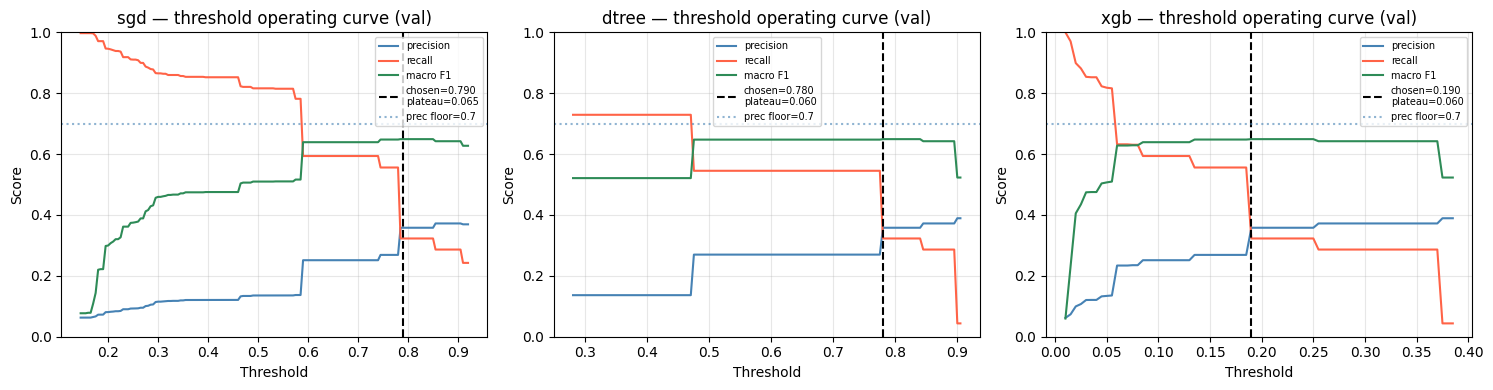

Saved → diag_threshold_curves.png


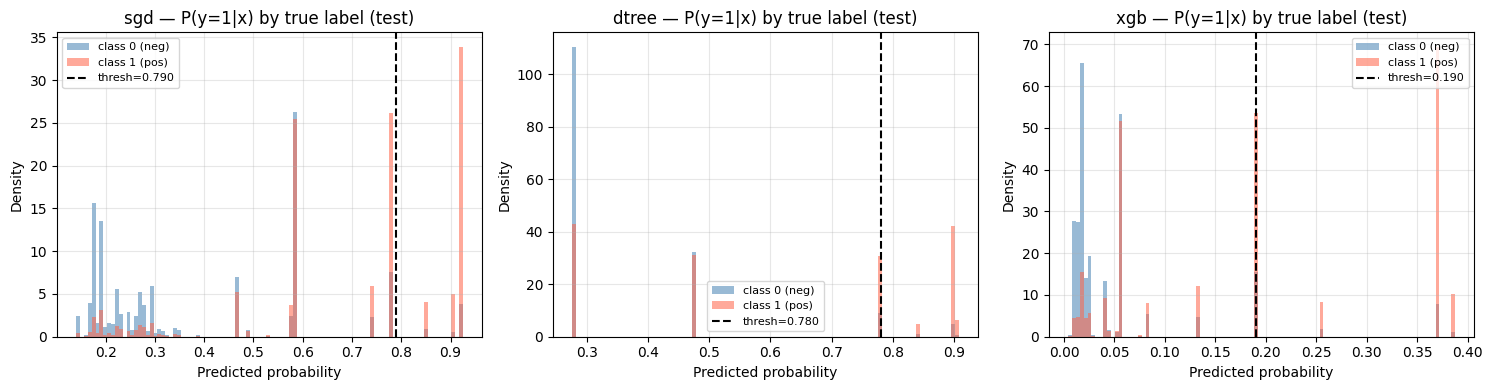

Saved → diag_prob_dist.png

=== Prediction agreement at each model's chosen threshold ===
  sgd vs dtree: 100.000000% identical predictions
  sgd vs xgb: 100.000000% identical predictions
  dtree vs xgb: 100.000000% identical predictions

=== Probability score distribution summary ===
  sgd: <0.05=0.0%  mid=100.0%  >0.95=0.0%
  dtree: <0.05=0.0%  mid=100.0%  >0.95=0.0%
  xgb: <0.05=62.2%  mid=37.8%  >0.95=0.0%


In [31]:
import matplotlib.pyplot as plt

DIAG_MAX_ROWS = 300_000  # cap for fast retraining; set None to use full data

# --- Build a single random fold on a subsample ---
_diag_df = (
    df_full.sample(n=min(DIAG_MAX_ROWS, len(df_full)), random_state=RANDOM_STATE)
    if DIAG_MAX_ROWS else df_full
)
_diag_X = _diag_df[[c for c in _diag_df.columns if c not in _BASE_EXCLUDE]]
_diag_y = _diag_df[TARGET_COL]

_tr_idx, _te_idx = train_test_split(_diag_X.index, test_size=0.2, random_state=RANDOM_STATE)
_X_tr_full = _diag_X.loc[_tr_idx]; _X_te = _diag_X.loc[_te_idx]
_y_tr_full = _diag_y.loc[_tr_idx]; _y_te = _diag_y.loc[_te_idx]
_X_tr, _X_val, _y_tr, _y_val = train_test_split(
    _X_tr_full, _y_tr_full, test_size=VAL_FRACTION, random_state=RANDOM_STATE
)
print(f'Diagnostic split — train: {len(_X_tr):,}  val: {len(_X_val):,}  test: {len(_X_te):,}')
print(f'Positive rate — train: {_y_tr.mean():.3%}  test: {_y_te.mean():.3%}')

# --- Fit each model, collect threshold curves (Stage C) + best threshold (Stage B) ---
_diag = {}
for _mname in MODELS_TO_RUN:
    print(f'  Fitting {_mname}...', end=' ', flush=True)
    _pipe = build_pipeline(THRESHOLD_MODELS[_mname]())
    _pipe.fit(_X_tr, _y_tr)

    _curve = build_threshold_curve(_pipe, _X_val, _y_val)   # Stage C curve on val
    _p_test = _pipe.predict_proba(_X_te)[:, 1]

    _best_t, _best_f1 = find_best_threshold(
        _pipe, _X_val, _y_val, min_precision=THRESH_MIN_PRECISION
    )
    # plateau: thresholds within 0.001 of peak macro F1
    _peak = _curve['f1_macro'].max()
    _plateau_w = float(_curve.loc[_curve['f1_macro'] >= _peak - 0.001, 'threshold'].pipe(
        lambda s: s.max() - s.min() if len(s) > 1 else 0.0
    ))

    _diag[_mname] = {
        'curve': _curve, 'p_test': _p_test,
        'best_t': _best_t, 'best_f1': _best_f1,
        'plateau_width': _plateau_w,
        'pred_test': (_p_test >= _best_t).astype(int),
    }
    print(f'best_t={_best_t:.3f}  val_macro_f1={_best_f1:.4f}  plateau_width={_plateau_w:.3f}')

# ── Plot 1 (Stage C): precision / recall / F1 operating curves ───────────────
fig, axes = plt.subplots(1, len(MODELS_TO_RUN), figsize=(5 * len(MODELS_TO_RUN), 4))
if len(MODELS_TO_RUN) == 1:
    axes = [axes]
for ax, _mname in zip(axes, MODELS_TO_RUN):
    info = _diag[_mname]; c = info['curve']
    ax.plot(c['threshold'], c['precision'], label='precision', lw=1.5, color='steelblue')
    ax.plot(c['threshold'], c['recall'],    label='recall',    lw=1.5, color='tomato')
    ax.plot(c['threshold'], c['f1_macro'],  label='macro F1',  lw=1.5, color='seagreen')
    ax.axvline(info['best_t'], color='black', linestyle='--',
               label=f"chosen={info['best_t']:.3f}\nplateau={info['plateau_width']:.3f}")
    if THRESH_MIN_PRECISION:
        ax.axhline(THRESH_MIN_PRECISION, color='steelblue', linestyle=':', alpha=0.6,
                   label=f'prec floor={THRESH_MIN_PRECISION}')
    ax.set_title(f'{_mname} — threshold operating curve (val)')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / 'diag_threshold_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → diag_threshold_curves.png')

# ── Plot 2: probability distributions by true label (bimodal check) ──────────
fig, axes = plt.subplots(1, len(MODELS_TO_RUN), figsize=(5 * len(MODELS_TO_RUN), 4))
if len(MODELS_TO_RUN) == 1:
    axes = [axes]
for ax, _mname in zip(axes, MODELS_TO_RUN):
    info = _diag[_mname]; p = info['p_test']
    ax.hist(p[_y_te == 0], bins=100, alpha=0.55, density=True,
            color='steelblue', label='class 0 (neg)')
    ax.hist(p[_y_te == 1], bins=100, alpha=0.55, density=True,
            color='tomato', label='class 1 (pos)')
    ax.axvline(info['best_t'], color='black', linestyle='--',
               label=f"thresh={info['best_t']:.3f}")
    ax.set_title(f'{_mname} — P(y=1|x) by true label (test)')
    ax.set_xlabel('Predicted probability'); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RUN_DIR / 'diag_prob_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → diag_prob_dist.png')

# ── Check 3: prediction agreement between models ─────────────────────────────
print('\n=== Prediction agreement at each model\'s chosen threshold ===')
_names = list(MODELS_TO_RUN)
for _i in range(len(_names)):
    for _j in range(_i + 1, len(_names)):
        a, b = _names[_i], _names[_j]
        _agree = (_diag[a]['pred_test'] == _diag[b]['pred_test']).mean()
        print(f'  {a} vs {b}: {_agree:.6%} identical predictions')

print('\n=== Probability score distribution summary ===')
for _mname in MODELS_TO_RUN:
    p = _diag[_mname]['p_test']
    _pct_lo  = (p < 0.05).mean()
    _pct_hi  = (p > 0.95).mean()
    _pct_mid = ((p >= 0.05) & (p <= 0.95)).mean()
    print(f'  {_mname}: <0.05={_pct_lo:.1%}  mid={_pct_mid:.1%}  >0.95={_pct_hi:.1%}')